# IV. Thống kê dữ liệu

Phần này thực hiện phân tích chi tiết về bộ dữ liệu và trả lời các câu hỏi ở phần **III**

## 4.1 Import Libraries và Cấu hình

In [1]:
import ast
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import f_oneway, ttest_ind, mannwhitneyu, gaussian_kde, kruskal, shapiro

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import lightgbm as lgb

from mpl_toolkits.mplot3d import Axes3D

warnings.filterwarnings('ignore')

## 4.2 Tải dữ liệu

In [2]:
df = pd.read_csv('../dataset/track_data_final.csv')
print(f'Loaded {len(df):,} tracks')
df.head(3)

Loaded 8,778 tracks


,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album


## 4.3 Tiền xử lý dữ liệu

### Quy trình tổng quan

Tiền xử lý được thực hiện theo các bước sau:

1. **Chuyển đổi thời gian**: Chuyển `album_release_date` sang datetime để trích xuất năm
2. **Tạo biến phái sinh**: Thêm `duration_min`, `year` từ dữ liệu gốc
3. **Xử lý giá trị thiếu**: Loại bỏ các bản ghi với giá trị thiếu trong các cột quan trọng
4. **Chuyển đổi kiểu dữ liệu**: Chuyển đổi các cột số về đúng kiểu (int64)

Mỗi câu hỏi sẽ có bước tiền xử lý riêng để tạo tập dữ liệu con phù hợp.

### Bước 1: Chuyển đổi thời gian

In [3]:
df['album_release_date'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce')

### Bước 2: Tạo biến phái sinh

In [4]:
df['duration_min'] = df['track_duration_ms'] / 60000
df['year'] = df['album_release_date'].dt.year

### Bước 3: Xử lý giá trị thiếu

In [5]:
df = df.dropna(subset=['year', 'artist_popularity', 'artist_followers'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8772 entries, 0 to 8777
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8772 non-null   object        
 1   track_name          8772 non-null   object        
 2   track_number        8772 non-null   int64         
 3   track_popularity    8772 non-null   int64         
 4   track_duration_ms   8772 non-null   int64         
 5   explicit            8772 non-null   bool          
 6   artist_name         8772 non-null   object        
 7   artist_popularity   8772 non-null   float64       
 8   artist_followers    8772 non-null   float64       
 9   artist_genres       8772 non-null   object        
 10  album_id            8772 non-null   object        
 11  album_name          8772 non-null   object        
 12  album_release_date  8772 non-null   datetime64[ns]
 13  album_total_tracks  8772 non-null   int64         
 1

### Bước 4: Chuyển đổi kiểu dữ liệu

In [6]:
df['artist_popularity'] = df['artist_popularity'].astype('int64')
df['artist_followers'] = df['artist_followers'].astype('int64')
df['year'] = df['year'].astype('int64')

---

## 4.6 Câu hỏi 3: Golden duration analysis

### Question

Có tồn tại một khoảng thời lượng golden duration nào cho track mà trong đó những bài hát có độ phổ biến trung bình cao nhất không? Nếu có, khoảng này là bao nhiêu phút?

### A. Tiền xử lý

Sử dụng dữ liệu đã được làm sạch ở phần 4.3. Không cần tiền xử lý thêm.

### B. Phân tích

Phân tích thời lượng theo 2 cấp độ:

1. **Phân tích tổng quát**: Chia thời lượng thành 5 nhóm (<2p, 2-3p, 3-4p, 4-5p, >5p) để xem xu hướng chung
2. **Phân tích chi tiết**: Chia thời lượng thành các khoảng 0.5 phút để tìm thời lượng vàng chính xác
3. **Trực quan hóa**: Biểu đồ cột cho các nhóm, biểu đồ phân tán + đường xu hướng cho phân tích chi tiết

In [7]:
q3_df = df[['duration_min', 'track_popularity']].copy()

q3_df['duration_group'] = pd.cut(q3_df['duration_min'], 
                                   bins=[0, 2, 3, 4, 5, 100],
                                   labels=['<2p', '2-3p', '3-4p', '4-5p', '>5p'])

q3_group_stats = q3_df.groupby('duration_group')['track_popularity'].agg(['mean', 'median', 'count'])
q3_group_stats

,mean,median,count
duration_group,,,
<2p,38.212670,41.0,442
2-3p,48.407075,52.0,2120
3-4p,54.816291,62.0,4039
4-5p,55.330670,61.0,1627
>5p,50.255515,56.0,544


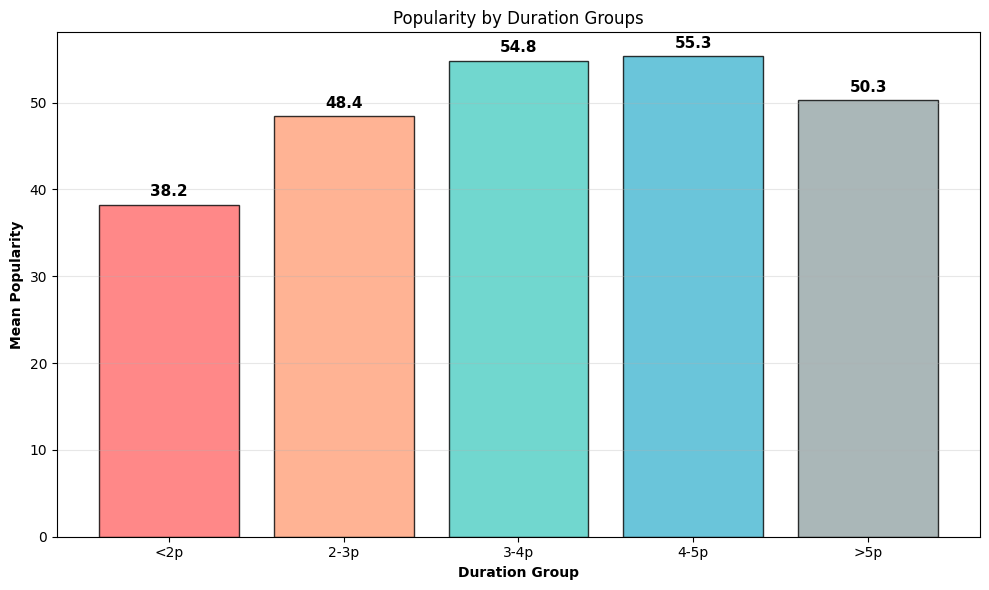

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(q3_group_stats))
bars = ax.bar(x_pos, q3_group_stats['mean'], 
               color=['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1', '#95A5A6'], 
               alpha=0.8, edgecolor='black')

for i, (bar, val) in enumerate(zip(bars, q3_group_stats['mean'])):
    ax.text(bar.get_x() + bar.get_width()/2., val + 1,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Duration Group', fontweight='bold')
ax.set_ylabel('Mean Popularity', fontweight='bold')
ax.set_title('Popularity by Duration Groups')
ax.set_xticks(x_pos)
ax.set_xticklabels(q3_group_stats.index)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
bins = np.arange(0, 8, 0.5)
q3_df['duration_bin'] = pd.cut(q3_df['duration_min'], bins=bins)

q3_detailed_stats = q3_df.groupby('duration_bin')['track_popularity'].agg(['mean', 'count'])
q3_detailed_stats = q3_detailed_stats[q3_detailed_stats['count'] >= 30].sort_values('mean', ascending=False)

q3_detailed_stats.head(10)

,mean,count
duration_bin,,
"(4.0, 4.5]",55.883871,1085
"(3.5, 4.0]",55.627000,2000
"(4.5, 5.0]",54.223247,542
"(3.0, 3.5]",54.021089,2039
"(5.0, 5.5]",53.504132,242
"(2.5, 3.0]",50.478639,1381
"(6.0, 6.5]",48.666667,51
"(5.5, 6.0]",47.455224,134
"(6.5, 7.0]",45.108108,37


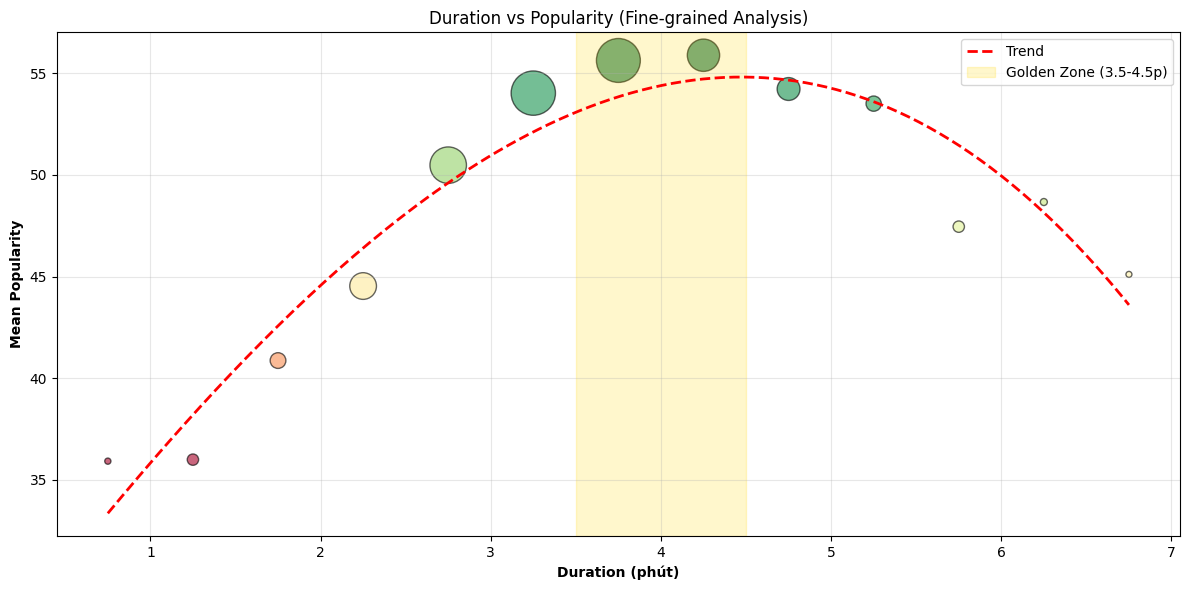

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

valid_stats = q3_detailed_stats[q3_detailed_stats.index.map(lambda x: x.right <= 7)]
bin_mids = [interval.mid for interval in valid_stats.index]

ax.scatter(bin_mids, valid_stats['mean'], s=valid_stats['count']/2, 
           c=valid_stats['mean'], cmap='RdYlGn', alpha=0.6, edgecolors='black')

z = np.polyfit(bin_mids, valid_stats['mean'], 3)
p = np.poly1d(z)
x_smooth = np.linspace(min(bin_mids), max(bin_mids), 200)
ax.plot(x_smooth, p(x_smooth), 'r--', linewidth=2, label='Trend')

ax.axvspan(3.5, 4.5, alpha=0.2, color='gold', label='Golden Zone (3.5-4.5p)')

ax.set_xlabel('Duration (phút)', fontweight='bold')
ax.set_ylabel('Mean Popularity', fontweight='bold')
ax.set_title('Duration vs Popularity (Fine-grained Analysis)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**H0** Các phân phối độ phổ biến của bài hát giữa các nhóm thời lượng khác nhau (<2 phút, 2-3 phút, 3-4 phút, 4-5 phút, >5 phút) là giống nhau.

$$H_0: F_{<2p}(x) = F_{2-3p}(x) = F_{3-4p}(x) = F_{4-5p}(x) = F_{>5p}(x)$$

**H1** Có ít nhất một nhóm thời lượng có phân phối độ phổ biến khác biệt với các nhóm còn lại.

$$H_1: \exists \, i \neq j : F_i(x) \neq F_j(x)$$

In [11]:
# Kiểm Định Kruskal-Wallis
from scipy.stats import kruskal

duration_test_groups = []
duration_labels = []
for dur_group in ['<2p', '2-3p', '3-4p', '4-5p', '>5p']:
    group_data = q3_df[q3_df['duration_group'] == dur_group]['track_popularity'].dropna()
    if len(group_data) > 0:
        duration_test_groups.append(group_data)
        duration_labels.append(dur_group)

print("Kiểm Định Kruskal-Wallis:\n")

h_stat, p_value_kw = kruskal(*duration_test_groups)
print(f"Giá trị H: {h_stat:.4f}")
print(f"Giá trị P: {p_value_kw:.4e}")

if p_value_kw < 0.05:
    print(f"Kết quả: Có sự khác biệt có ý nghĩa giữa các nhóm (p < 0.05)")
    means = [g.mean() for g in duration_test_groups]
    max_idx = np.argmax(means)
    print(f"Độ phổ biến trung bình cao nhất: {duration_labels[max_idx]} ({means[max_idx]:.2f})")
else:
    print("Kết quả: Không có sự khác biệt có ý nghĩa")

Kiểm Định Kruskal-Wallis:

Giá trị H: 348.3981
Giá trị P: 3.8890e-74
Kết quả: Có sự khác biệt có ý nghĩa giữa các nhóm (p < 0.05)
Độ phổ biến trung bình cao nhất: 4-5p (55.33)


### C. Kết quả & Giải thích

**Câu trả lời:** Có tồn tại thời lượng vàng - khoảng **3.5 - 4.5 phút** có độ phổ biến trung bình cao nhất (~55.6-55.9).

**Phát hiện chính:**

Độ phổ biến tăng dần từ bài hát ngắn (<2p: 38.2) đến trung bình (3-4p: 54.8) và đạt đỉnh ở 4-5p (55.3), sau đó giảm xuống khi bài hát quá dài (>5p: 50.3). Phân tích chi tiết cho thấy đỉnh chính xác ở 4.0-4.5 phút với độ phổ biến 55.9.

**Ý nghĩa thực tiễn:**

Nhà sản xuất và nhạc sĩ nên nhắm đến thời lượng 3.5-4.5 phút để tối ưu hóa độ phổ biến. Bài hát dưới 2 phút có xu hướng bị coi là thiếu nội dung (độ phổ biến thấp hơn 17 điểm so với vùng vàng), trong khi bài trên 5 phút có thể khiến người nghe bỏ qua hoặc mất hứng thú (giảm 5 điểm độ phổ biến).

**Hạn chế:**

Phân tích này không phân biệt thể loại - có thể một số thể loại (EDM, cổ điển) có thời lượng tối ưu khác. Tập dữ liệu tập trung vào pop/hip-hop đại chúng nên các phát hiện có thể không khái quát cho tất cả các phong cách âm nhạc.

---

## 4.7 Câu hỏi 4: Số lượng bài hát và độ nổi tiếng nghệ sĩ

### Question

Nghệ sĩ phát hành nhiều bài hát hơn thì có đạt được độ nổi tiếng trung bình cao hơn so với nghệ sĩ phát hành ít bài hơn không?

### A. Tiền xử lý

Tổng hợp dữ liệu theo nghệ sĩ để đếm số bài hát và tính độ phổ biến trung bình cho mỗi nghệ sĩ.

In [12]:
q4_artist_stats = df.groupby('artist_name').agg({
    'track_id': 'count',
    'artist_popularity': 'first',
    'artist_followers': 'first'
}).rename(columns={'track_id': 'track_count'})

q4_artist_stats['output_strategy'] = pd.cut(q4_artist_stats['track_count'], 
                                              bins=[0, 20, 50, 100, 1000],
                                              labels=['Low (1-20)', 'Medium (21-50)', 'High (51-100)', 'Very High (>100)'])

q4_artist_stats.head()

,track_count,artist_popularity,artist_followers,output_strategy
artist_name,,,,
$uicideboy$,2,83,8957416,Low (1-20)
'Ery Noice,1,25,11720,Low (1-20)
(((()))),1,51,49519,Low (1-20)
*NSYNC,1,69,3088613,Low (1-20)
-,1,28,714,Low (1-20)


### B. Phân tích

**Phương pháp phân tích:**

Để trả lời câu hỏi này, nhóm sử dụng 2 phương pháp:

1. **So sánh theo nhóm**: Chia nghệ sĩ thành 4 nhóm theo chiến lược sản xuất (Thấp: 1-20 bài, Trung bình: 21-50, Cao: 51-100, Rất cao: >100) để so sánh độ phổ biến trung bình/trung vị của nghệ sĩ giữa các nhóm
2. **Phân tích tương quan**: Biểu đồ phân tán giữa số lượng bài hát và độ phổ biến nghệ sĩ với đường xu hướng để thấy mối quan hệ

**Kết quả mong đợi:**
- Bảng thống kê: Trung bình, trung vị, độ lệch chuẩn của độ phổ biến nghệ sĩ và người theo dõi cho mỗi nhóm chiến lược sản xuất
- Trực quan hóa 1: Biểu đồ cột so sánh độ phổ biến trung bình của nghệ sĩ qua các nhóm
- Trực quan hóa 2: Biểu đồ phân tán với đường xu hướng hiển thị mối quan hệ giữa số lượng bài hát và độ phổ biến nghệ sĩ

**Lý do:** Phân tích theo nhóm giúp thấy sự khác biệt rõ ràng giữa các chiến lược, trong khi biểu đồ phân tán tiết lộ mô hình mối quan hệ chi tiết (tuyến tính, bậc hai, hoặc bão hòa).

In [13]:
q4_strategy_stats = q4_artist_stats.groupby('output_strategy').agg({
    'artist_popularity': ['mean', 'median', 'std'],
    'artist_followers': ['mean', 'median'],
    'track_count': 'count'
}).round(2)

q4_strategy_stats.columns = ['_'.join(col) for col in q4_strategy_stats.columns]
q4_strategy_stats

,artist_popularity_mean,artist_popularity_median,artist_popularity_std,artist_followers_mean,artist_followers_median,track_count_count
output_strategy,,,,,,
Low (1-20),52.94,57.0,19.56,2.375346e+06,391063.5,2484
Medium (21-50),79.84,82.5,8.45,2.543166e+07,22876939.0,44
High (51-100),87.00,88.0,4.53,6.386942e+07,50411829.0,16
Very High (>100),94.33,93.0,5.13,1.218964e+08,112918137.0,3


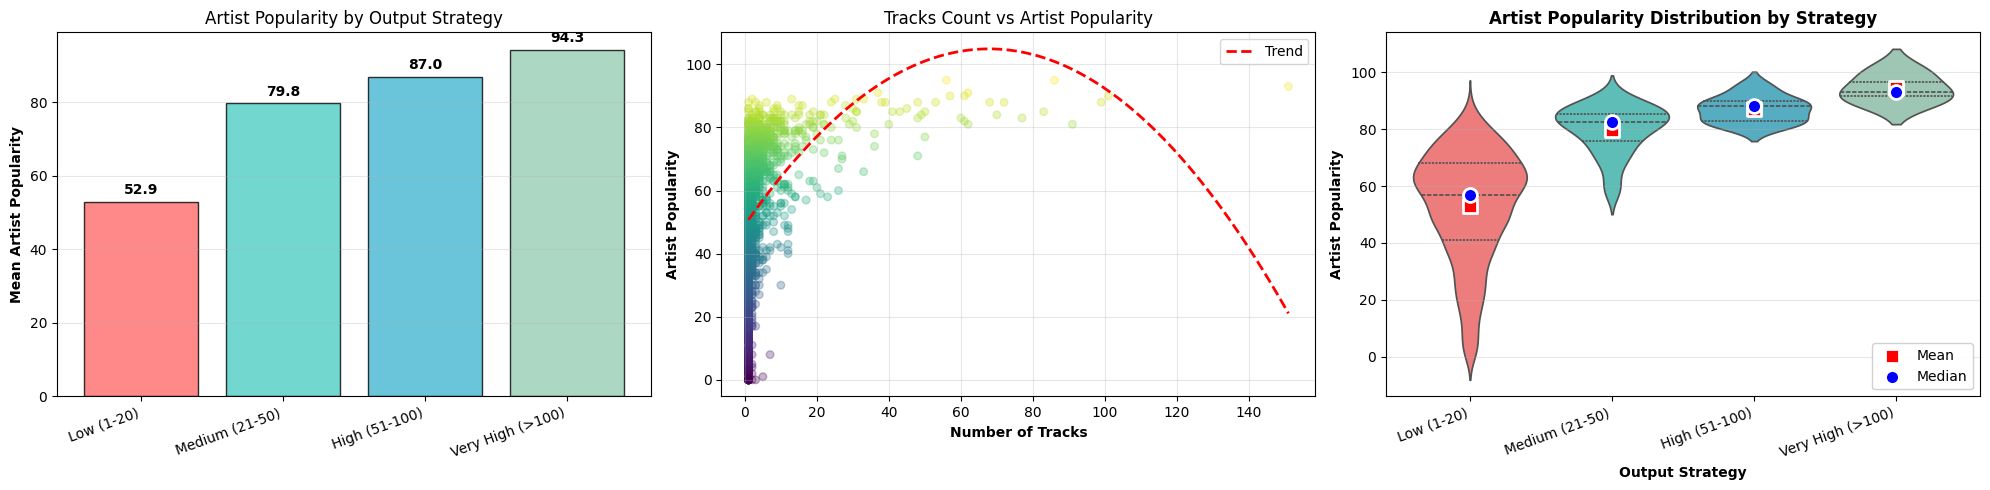

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].bar(range(len(q4_strategy_stats)), q4_strategy_stats['artist_popularity_mean'],
            color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q4_strategy_stats)))
axes[0].set_xticklabels(q4_strategy_stats.index, rotation=20, ha='right')
axes[0].set_ylabel('Mean Artist Popularity', fontweight='bold')
axes[0].set_title('Artist Popularity by Output Strategy')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q4_strategy_stats['artist_popularity_mean']):
    axes[0].text(i, val + 2, f'{val:.1f}', ha='center', fontweight='bold')

q4_plot_df = q4_artist_stats[q4_artist_stats['track_count'] <= 200]
axes[1].scatter(q4_plot_df['track_count'], q4_plot_df['artist_popularity'], 
                alpha=0.3, s=30, c=q4_plot_df['artist_popularity'], cmap='viridis')

z = np.polyfit(q4_plot_df['track_count'], q4_plot_df['artist_popularity'], 2)
p = np.poly1d(z)
x_line = np.linspace(q4_plot_df['track_count'].min(), q4_plot_df['track_count'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')

axes[1].set_xlabel('Number of Tracks', fontweight='bold')
axes[1].set_ylabel('Artist Popularity', fontweight='bold')
axes[1].set_title('Tracks Count vs Artist Popularity')
axes[1].legend()
axes[1].grid(alpha=0.3)

strategy_order = ['Low (1-20)', 'Medium (21-50)', 'High (51-100)', 'Very High (>100)']
sns.violinplot(data=q4_artist_stats, x='output_strategy', y='artist_popularity', order=strategy_order,
               palette=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], ax=axes[2], inner='quartile')

# Vẽ thêm mean và median cho mỗi strategy
for i, strategy in enumerate(strategy_order):
    strategy_data = q4_artist_stats[q4_artist_stats['output_strategy'] == strategy]['artist_popularity']
    mean_val = strategy_data.mean()
    median_val = strategy_data.median()
    
    # Vẽ mean (hình vuông đỏ)
    axes[2].scatter(i, mean_val, color='red', s=100, marker='s', zorder=3, 
                    edgecolors='white', linewidths=2, label='Mean' if i == 0 else '')
    # Vẽ median (hình tròn xanh)
    axes[2].scatter(i, median_val, color='blue', s=100, marker='o', zorder=3, 
                    edgecolors='white', linewidths=2, label='Median' if i == 0 else '')

axes[2].set_title('Artist Popularity Distribution by Strategy', fontweight='bold')
axes[2].set_xlabel('Output Strategy', fontweight='bold')
axes[2].set_ylabel('Artist Popularity', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=20, ha='right')
axes[2].grid(alpha=0.3, axis='y')
axes[2].legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

**H0:** Các phân phối độ phổ biến của nghệ sĩ giữa các nhóm chiến lược sản xuất khác nhau (Low 1-20 bài, Medium 21-50 bài, High 51-100 bài, Very High >100 bài) là giống nhau.

$$H_0: F_{Low}(x) = F_{Medium}(x) = F_{High}(x) = F_{VeryHigh}(x)$$

**H1:** Có ít nhất một nhóm chiến lược sản xuất có phân phối độ phổ biến nghệ sĩ khác biệt với các nhóm còn lại.

$$H_1: \exists \, i \neq j : F_i(x) \neq F_j(x)$$

In [15]:
strategy_test_groups = []
strategy_labels = []
for strategy in ['Low (1-20)', 'Medium (21-50)', 'High (51-100)', 'Very High (>100)']:
    group_data = q4_artist_stats[q4_artist_stats['output_strategy'] == strategy]['artist_popularity'].dropna()
    if len(group_data) > 0:
        strategy_test_groups.append(group_data)
        strategy_labels.append(strategy)

print("Kiểm Định Kruskal-Wallis:\n")

h_stat_q4, p_value_kw_q4 = kruskal(*strategy_test_groups)
print(f"Giá trị H: {h_stat_q4:.4f}")
print(f"Giá trị P: {p_value_kw_q4:.4e}")

if p_value_kw_q4 < 0.05:
    print(f"Kết quả: Có sự khác biệt có ý nghĩa giữa các nhóm (p < 0.05)")
    means_q4 = [g.mean() for g in strategy_test_groups]
    max_idx_q4 = np.argmax(means_q4)
    print(f"Độ phổ biến trung bình cao nhất: {strategy_labels[max_idx_q4]} ({means_q4[max_idx_q4]:.2f})")
else:
    print("Kết quả: Không có sự khác biệt có ý nghĩa")

Kiểm Định Kruskal-Wallis:

Giá trị H: 145.3303
Giá trị P: 2.6791e-31
Kết quả: Có sự khác biệt có ý nghĩa giữa các nhóm (p < 0.05)
Độ phổ biến trung bình cao nhất: Very High (>100) (94.33)


### C. Kết quả & Giải thích

**Câu trả lời:** Có, nghệ sĩ phát hành nhiều bài hát hơn đạt được độ phổ biến nghệ sĩ cao hơn đáng kể.

**Phát hiện chính:**

Độ phổ biến nghệ sĩ tăng mạnh theo số lượng bài hát: Sản lượng thấp (1-20 bài) có độ phổ biến trung bình 52.9, trong khi sản lượng Rất cao (>100 bài) đạt 94.3 - tăng gần gấp đôi. Sản lượng trung bình (21-50 bài) đã có độ phổ biến 79.8, cho thấy sản lượng nhất quán là yếu tố quan trọng để xây dựng danh tiếng nghệ sĩ.

Lượng người theo dõi nghệ sĩ cũng tăng theo cùng mô hình: Sản lượng thấp có trung bình 2.4 triệu người theo dõi, sản lượng Rất cao có 121.9 triệu - tăng hơn 50 lần, chứng tỏ chiến lược sản xuất năng suất không chỉ tăng điểm độ phổ biến mà còn xây dựng được lượng người hâm mộ khổng lồ.

Biểu đồ phân tán cho thấy mối quan hệ không hoàn toàn tuyến tính - có hiệu suất giảm dần sau ~100 bài hát, và một số nghệ sĩ với sản lượng thấp vẫn có độ phổ biến cao (có thể do chất lượng hoặc các bản hit lan truyền).

Biểu đồ violin cho thấy rằng các chiến lược medium, high, và very high có phân bố tập trung rất nhiều ở vùng 80-90. Trong khi đó chiến lược low chỉ tập trung quanh vùng 60-70 và có phương sai lớn. Điều này cho thấy rằng chiến lược sản xuất nhạc ổn định và đều đặn thực sự giúp người nghệ sĩ trở nên nổi tiếng hơn, trong khi chiến lược sản xuất ít khiến sự nổi tiếng đôi khi phụ thuộc vào may mắn.

**Ý nghĩa thực tiễn:**

Nghệ sĩ mới nổi nên nhắm đến việc phát hành nhất quán thay vì chỉ sản xuất một vài bài hát - dữ liệu cho thấy việc chuyển từ sản lượng Thấp sang Trung bình (21-50 bài) mang lại bước nhảy vọt lớn nhất về độ phổ biến (+26.9 điểm). Các hãng thu âm nên đầu tư vào các nghệ sĩ có khả năng duy trì sản lượng ổn định, vì đây là yếu tố dự báo mạnh mẽ cho thành công dài hạn.

**Hạn chế:**

Phân tích này không tính đến thời gian - nghệ sĩ có 100 bài trong 1 năm khác với 100 bài trong 10 năm. Cũng không phân biệt chất lượng - độ phổ biến cao có thể do số lượng hoặc do có các bản hit trong danh mục.

---

## 4.8 Câu hỏi 5: Classic songs vs Recent songs

### Question

Những bài hát phát hành từ 2009-2015 (classic songs) có còn giữ được độ phổ biến cao so với những bài hát phát hành từ 2020-2025 (recent songs) không?

### A. Tiền xử lý

Lọc dữ liệu theo 2 khoảng thời gian và loại bỏ các bài hát có độ phổ biến = 0 (bài hát chết).

In [16]:
q5_classic = df[(df['year'] >= 2009) & (df['year'] <= 2015)].copy()
q5_recent = df[(df['year'] >= 2020) & (df['year'] <= 2025)].copy()

q5_classic = q5_classic[q5_classic['track_popularity'] > 0]
q5_recent = q5_recent[q5_recent['track_popularity'] > 0]

print(f'Classic songs (2009-2015): {len(q5_classic):,} tracks')
print(f'Recent songs (2020-2025): {len(q5_recent):,} tracks')

Classic songs (2009-2015): 1,944 tracks
Recent songs (2020-2025): 3,182 tracks


### B. Phân tích

**Phương pháp phân tích:**

So sánh phân bố độ phổ biến giữa 2 khoảng thời gian sử dụng:

1. **Thống kê mô tả**: Trung bình, trung vị, tứ phân vị để so sánh xu hướng trung tâm và độ phân tán
2. **So sánh phân bố**: Biểu đồ hộp và biểu đồ tần suất để trực quan hóa toàn bộ phân bố

**Kết quả mong đợi:**
- Bảng thống kê tóm tắt so sánh kinh điển và gần đây
- Biểu đồ hộp hiển thị so sánh phân bố
- Biểu đồ tần suất chồng lớp hiển thị phân bố độ phổ biến cho cả 2 nhóm

**Lý do:** Biểu đồ hộp tiết lộ các giá trị ngoại lai và cấu trúc tứ phân vị, biểu đồ tần suất hiển thị hình dạng của phân bố (chuẩn, lệch, hai đỉnh).

In [17]:
q5_stats = pd.DataFrame({
    'Classic (2009-2015)': q5_classic['track_popularity'].describe(),
    'Recent (2020-2025)': q5_recent['track_popularity'].describe()
}).T

q5_stats

,count,mean,std,min,25%,50%,75%,max
Classic (2009-2015),1944.0,55.286008,20.596995,1.0,44.0,58.0,71.0,91.0
Recent (2020-2025),3182.0,55.008485,20.723330,1.0,41.0,59.0,71.0,100.0


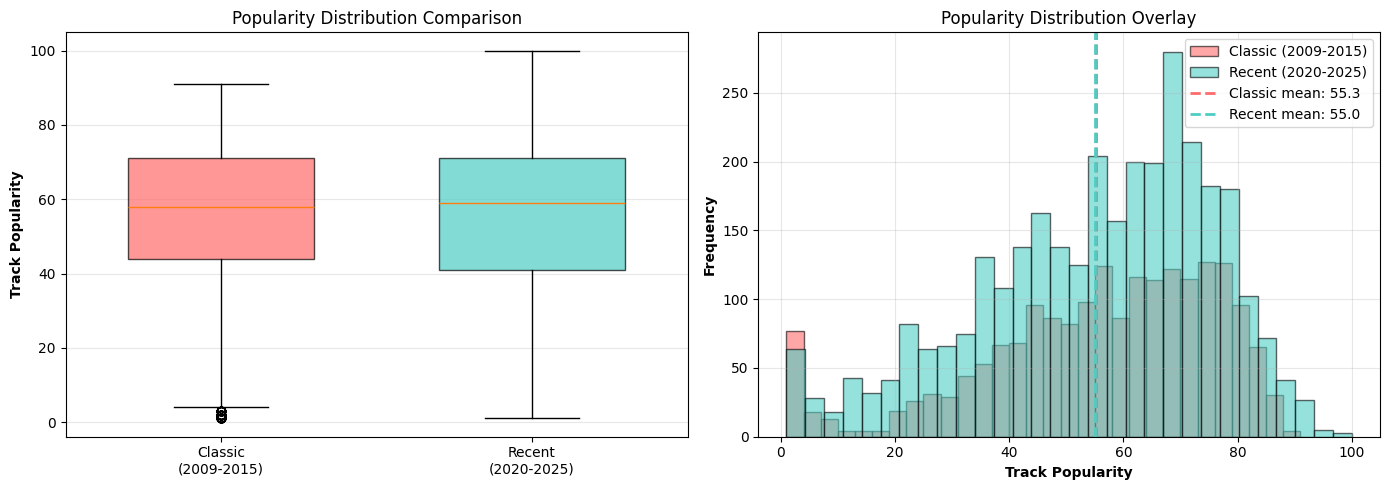

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

box_data = [q5_classic['track_popularity'], q5_recent['track_popularity']]
bp = axes[0].boxplot(box_data, labels=['Classic\n(2009-2015)', 'Recent\n(2020-2025)'],
                      patch_artist=True, widths=0.6)

colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel('Track Popularity', fontweight='bold')
axes[0].set_title('Popularity Distribution Comparison')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(q5_classic['track_popularity'], bins=30, alpha=0.6, 
             label='Classic (2009-2015)', color='#FF6B6B', edgecolor='black')
axes[1].hist(q5_recent['track_popularity'], bins=30, alpha=0.6, 
             label='Recent (2020-2025)', color='#4ECDC4', edgecolor='black')

axes[1].axvline(q5_classic['track_popularity'].mean(), color='#FF6B6B', 
                linestyle='--', linewidth=2, label=f"Classic mean: {q5_classic['track_popularity'].mean():.1f}")
axes[1].axvline(q5_recent['track_popularity'].mean(), color='#4ECDC4', 
                linestyle='--', linewidth=2, label=f"Recent mean: {q5_recent['track_popularity'].mean():.1f}")

axes[1].set_xlabel('Track Popularity', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Popularity Distribution Overlay')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**H0:** Dữ liệu độ phổ biến của bài hát tuân theo phân phối chuẩn.

$$H_0: X \sim N(\mu, \sigma^2)$$

**H1:** Dữ liệu độ phổ biến của bài hát không tuân theo phân phối chuẩn.

$$H_1: X \nsim N(\mu, \sigma^2)$$

In [19]:
groups_q5 = {
    'Cổ Điển (2009-2015)': q5_classic['track_popularity'],
    'Gần Đây (2020-2025)': q5_recent['track_popularity']
}

for name, data in groups_q5.items():
    print(f"{name} (n={len(data)}):")
    print(f"  Trung bình: {data.mean():.2f}, Trung vị: {data.median():.2f}")
    print(f"  Độ lệch: {data.skew():.3f}, Độ nhọn: {data.kurtosis():.3f}")
    
    if len(data) <= 5000:
        stat_sw, p_sw = shapiro(data)
        print(f"  Shapiro-Wilk: W={stat_sw:.4f}, giá trị p={p_sw:.4e}")
        print(f"  Kết quả: {'Không phân phối chuẩn' if p_sw < 0.05 else 'Phân phối chuẩn'}\n")

Cổ Điển (2009-2015) (n=1944):
  Trung bình: 55.29, Trung vị: 58.00
  Độ lệch: -0.850, Độ nhọn: 0.282
  Shapiro-Wilk: W=0.9357, giá trị p=3.4071e-28
  Kết quả: Không phân phối chuẩn

Gần Đây (2020-2025) (n=3182):
  Trung bình: 55.01, Trung vị: 59.00
  Độ lệch: -0.601, Độ nhọn: -0.249
  Shapiro-Wilk: W=0.9636, giá trị p=1.2972e-27
  Kết quả: Không phân phối chuẩn



**Kết luận:**
- Cả 2 nhóm đều KHÔNG tuân theo phân phối chuẩn (p < 0.05)
- Nên sử dụng Mann-Whitney U test (non-parametric)

**H0:** Phân phối độ phổ biến của bài hát Cổ Điển (2009-2015) và bài hát Gần Đây (2020-2025) là giống nhau.

$$H_0: F_{classic}(x) = F_{recent}(x)$$

**H1:** Phân phối độ phổ biến của bài hát Cổ Điển và bài hát Gần Đây là khác nhau.

$$H_1: F_{classic}(x) \neq F_{recent}(x)$$

In [20]:
classic_data = q5_classic['track_popularity'].dropna()
recent_data = q5_recent['track_popularity'].dropna()

print("Kiểm Định Mann-Whitney U:\n")

u_stat, p_value = mannwhitneyu(classic_data, recent_data, alternative='two-sided')
print(f"Giá trị U: {u_stat:.4f}")
print(f"Giá trị P: {p_value:.4e}")

if p_value < 0.05:
    print(f"Kết quả: Có sự khác biệt có ý nghĩa (p < 0.05)")
    print(f"Trung bình Cổ Điển: {classic_data.mean():.2f}")
    print(f"Trung bình Gần Đây: {recent_data.mean():.2f}")
else:
    print("Kết quả: Không có sự khác biệt có ý nghĩa")

Kiểm Định Mann-Whitney U:

Giá trị U: 3137379.0000
Giá trị P: 3.8692e-01
Kết quả: Không có sự khác biệt có ý nghĩa


### C. Kết quả & Giải thích

**Câu trả lời:** Bài hát kinh điển (2009-2015) và Bài hát gần đây (2020-2025) có độ phổ biến gần như tương đương - không có sự khác biệt đáng kể.

**Phát hiện chính:**
- Độ phổ biến trung bình gần như giống hệt nhau: Kinh điển 55.3 so với Gần đây 55.0 (chỉ chênh 0.28 điểm). 
- Tuy nhiên, biểu đồ hộp cũng cho thấy rằng các bài hát gần đây thường có độ phổ biến lớn nhất (các bài hit) cao hơn rõ rệt so với các bài hát cũ.

**Ý nghĩa thực tiễn:**
Các bài hát kinh điển đã vượt qua thử thách của thời gian - những bài từ 2009-2015 vẫn duy trì độ phổ biến tương đương với các phát hành gần đây. Điều này gợi ý nghệ sĩ nên tiếp tục khai thác lại kho nhạc cũ (remaster, live, TikTok trend…) bởi mức độ phổ biến trong dài hạn vẫn được duy trì mạnh mẽ.

**Hạn chế:**
Tập dữ liệu không phân biệt được liệu các bài hát cũ duy trì độ phổ biến do nghe tự nhiên hay do xu hướng hoài cổ. 

---

## 4.9 Câu hỏi 6: Đặc trưng quan trọng theo từng phân khúc

### Question

Những đặc trưng nào (features) quan trọng nhất thay đổi theo từng cụm (segment) độ nổi tiếng? Liệu mỗi phân khúc popularity có các yếu tố quyết định riêng biệt không?

### A. Tiền xử lý

Chia các bài hát thành 5 phân khúc dựa trên độ phổ biến, sau đó huấn luyện mô hình Random Forest cho từng phân khúc để trích xuất tầm quan trọng của đặc trưng.

In [21]:
q6_df = df.copy()

q6_df['explicit_encoded'] = q6_df['explicit'].astype(int)

album_dummies = pd.get_dummies(q6_df['album_type'], prefix='album', drop_first=False)
q6_df = pd.concat([q6_df, album_dummies], axis=1)

def count_genres(genre_str):
    if pd.isna(genre_str) or genre_str == '[]':
        return 0
    try:
        genres = ast.literal_eval(genre_str)
        return len(genres) if isinstance(genres, list) else 0
    except:
        return 0

q6_df['num_genres'] = q6_df['artist_genres'].apply(count_genres)

q6_df['popularity_segment'] = pd.cut(q6_df['track_popularity'], 
                                      bins=[0, 20, 40, 60, 80, 100],
                                      labels=['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)', 
                                              'High (60-80)', 'Very High (80-100)'])

q6_df = q6_df.dropna(subset=['num_genres'])

print(f'Segment distribution:')
print(q6_df['popularity_segment'].value_counts().sort_index())

Segment distribution:
popularity_segment
Very Low (0-20)        578
Low (20-40)           1269
Medium (40-60)        2391
High (60-80)          3396
Very High (80-100)     619
Name: count, dtype: int64


### B. Phân tích

**Phương pháp phân tích:**

Sử dụng các mô hình Random Forest cụ thể cho từng phân khúc để xác định tầm quan trọng của đặc trưng cho mỗi cấp độ phổ biến:

1. **Huấn luyện các mô hình RF riêng biệt**: Một mô hình cho mỗi phân khúc (tổng cộng 5 phân khúc) để nắm bắt các mô hình cụ thể của phân khúc
2. **Trích xuất tầm quan trọng của đặc trưng**: Sử dụng feature_importances_ tích hợp của RF để xếp hạng các đặc trưng theo đóng góp
3. **So sánh giữa các phân khúc**: Trực quan hóa sự thay đổi tầm quan trọng của đặc trưng qua các cấp độ phổ biến

**Các đặc trưng được phân tích:**
- `artist_popularity`: Độ nổi tiếng nghệ sĩ
- `artist_followers`: Quy mô lượng người hâm mộ
- `explicit_encoded`: Xếp hạng nội dung (0/1)
- `album_type_encoded`: Chiến lược phát hành (0/1/2)
- `num_genres`: Sự đa dạng thể loại
- `duration_min`: Độ dài bài hát

**Kết quả mong đợi:**
- Bảng tầm quan trọng của đặc trưng cho mỗi phân khúc
- Biểu đồ nhiệt hiển thị sự biến đổi tầm quan trọng qua các phân khúc
- Biểu đồ cột so sánh các đặc trưng hàng đầu mỗi phân khúc

**Lý do:** Các mức độ phổ biến khác nhau có thể yêu cầu các yếu tố thành công khác nhau - các bài hát ngách (độ phổ biến thấp) có thể dựa vào thời lượng/chất lượng, trong khi các bản hit lan truyền (độ phổ biến cao) yêu cầu danh tiếng nghệ sĩ.

In [22]:
q6_features = ['artist_popularity', 'artist_followers', 'explicit_encoded', 
               'album_album', 'album_compilation', 'album_single',
               'num_genres', 'duration_min'] 
q6_target = 'track_popularity'

q6_importance_results = {}
q6_r2_scores = {}

for segment in q6_df['popularity_segment'].unique():
    segment_data = q6_df[q6_df['popularity_segment'] == segment]
    
    if len(segment_data) < 50:
        continue
    
    X = segment_data[q6_features]
    y = segment_data[q6_target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    importances = pd.Series(rf.feature_importances_, index=q6_features)
    q6_importance_results[segment] = importances
    q6_r2_scores[segment] = rf.score(X_test, y_test)

q6_importance_df = pd.DataFrame(q6_importance_results).T
q6_importance_df

,artist_popularity,artist_followers,explicit_encoded,album_album,album_compilation,album_single,num_genres,duration_min
High (60-80),0.180561,0.289706,0.029723,0.017853,0.008431,0.012508,0.058058,0.403161
Medium (40-60),0.216273,0.323634,0.026759,0.013800,0.022661,0.016172,0.051397,0.329303
Low (20-40),0.230357,0.293139,0.020547,0.017550,0.014129,0.012958,0.052149,0.359172
Very High (80-100),0.223551,0.353872,0.025775,0.012094,0.000205,0.016775,0.039986,0.327741
Very Low (0-20),0.418353,0.209818,0.015907,0.015753,0.032955,0.022675,0.065813,0.218726


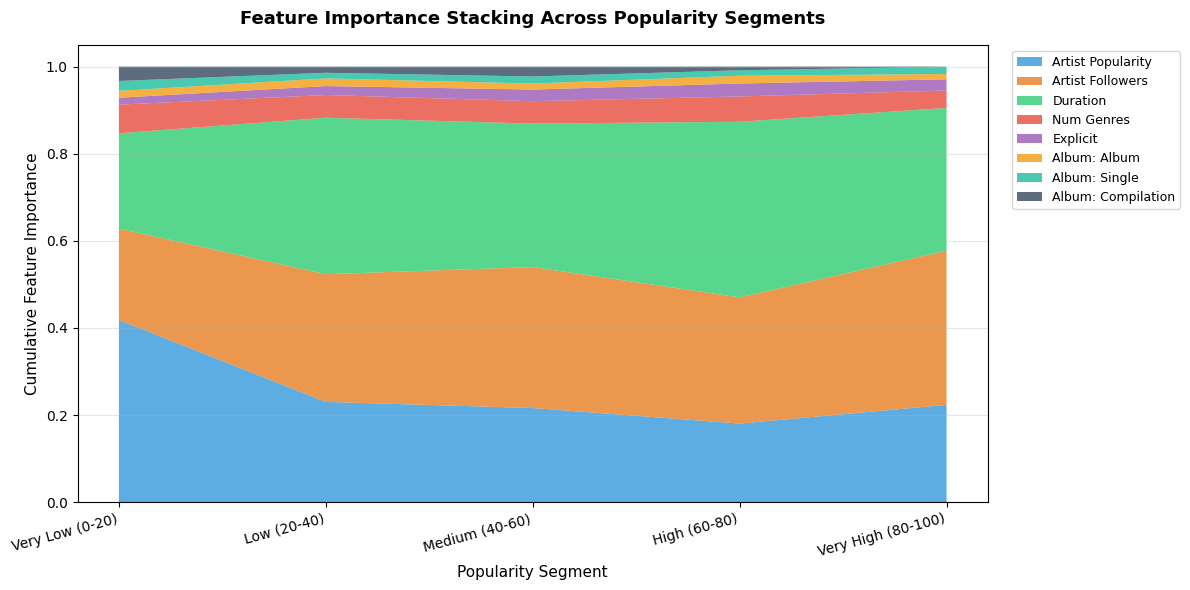

In [23]:
segments_order = ['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)', 
                  'High (60-80)', 'Very High (80-100)']

q6_plot_df = q6_importance_df.loc[segments_order]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#34495e']

ax.stackplot(range(len(segments_order)), 
             q6_plot_df['artist_popularity'],
             q6_plot_df['artist_followers'],
             q6_plot_df['duration_min'],
             q6_plot_df['num_genres'],
             q6_plot_df['explicit_encoded'],
             q6_plot_df['album_album'],
             q6_plot_df['album_single'],
             q6_plot_df['album_compilation'],
             labels=['Artist Popularity', 'Artist Followers', 'Duration', 'Num Genres', 
                     'Explicit', 'Album: Album', 'Album: Single', 'Album: Compilation'],
             colors=colors,
             alpha=0.8)

ax.set_xticks(range(len(segments_order)))
ax.set_xticklabels(segments_order, rotation=15, ha='right')
ax.set_ylabel('Cumulative Feature Importance', fontsize=11)
ax.set_xlabel('Popularity Segment', fontsize=11)
ax.set_title('Feature Importance Stacking Across Popularity Segments', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_feature_importance_stacked.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

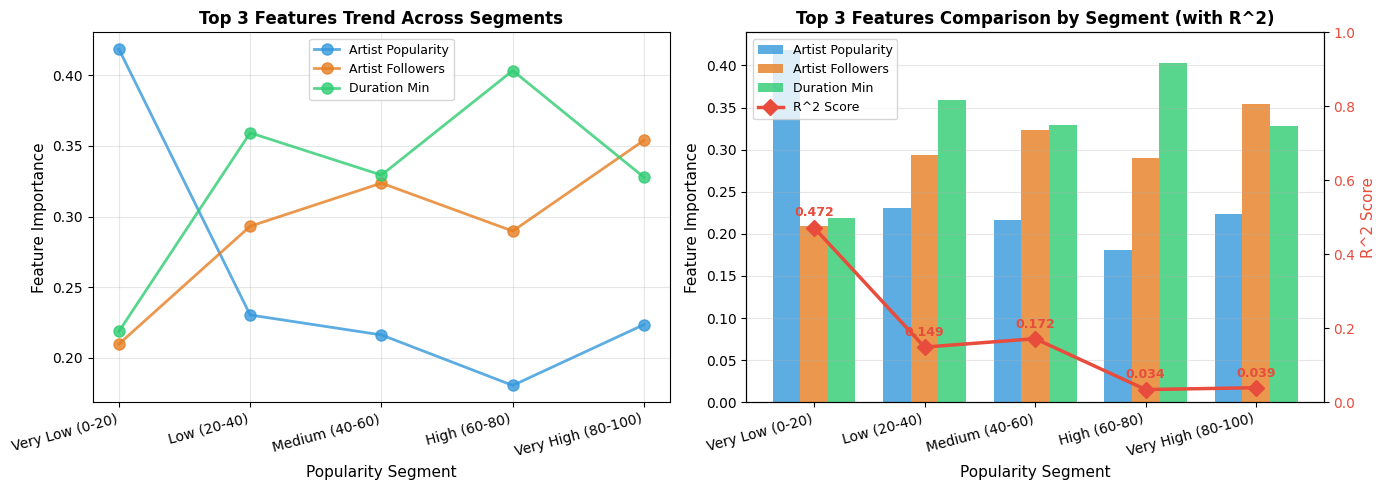

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = ['artist_popularity', 'artist_followers', 'duration_min']
colors_map = {'artist_popularity': '#3498db', 
              'artist_followers': '#e67e22', 
              'duration_min': '#2ecc71'}

for feature in top_features:
    axes[0].plot(range(len(segments_order)), q6_plot_df[feature], 
                 marker='o', linewidth=2, markersize=8, 
                 label=feature.replace('_', ' ').title(), 
                 color=colors_map[feature], alpha=0.8)

axes[0].set_xticks(range(len(segments_order)))
axes[0].set_xticklabels(segments_order, rotation=15, ha='right')
axes[0].set_ylabel('Feature Importance', fontsize=11)
axes[0].set_xlabel('Popularity Segment', fontsize=11)
axes[0].set_title('Top 3 Features Trend Across Segments', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='both', alpha=0.3)

x_pos = np.arange(len(segments_order))
width = 0.25

for idx, feature in enumerate(top_features):
    axes[1].bar(x_pos + idx * width, q6_plot_df[feature], width, 
                label=feature.replace('_', ' ').title(), 
                color=colors_map[feature], alpha=0.8)

r2_values = [q6_r2_scores[seg] for seg in segments_order]
ax2 = axes[1].twinx()
ax2.plot(x_pos + width, r2_values, color='#e74c3c', marker='D', linewidth=2.5, 
         markersize=8, label='R^2 Score', zorder=10)
ax2.set_ylabel('R^2 Score', fontsize=11, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, 1)

for i, r2 in enumerate(r2_values):
    ax2.text(x_pos[i] + width, r2 + 0.03, f'{r2:.3f}', 
             ha='center', fontsize=9, color='#e74c3c', fontweight='bold')

axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(segments_order, rotation=15, ha='right')
axes[1].set_ylabel('Feature Importance', fontsize=11)
axes[1].set_xlabel('Popularity Segment', fontsize=11)
axes[1].set_title('Top 3 Features Comparison by Segment (with R^2)', fontsize=12, fontweight='bold')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_top_features_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Mỗi phân khúc độ phổ biến có các yếu tố thành công hoàn toàn khác nhau - không có công thức chung.

**Phát hiện chính:**

Phân khúc Rất thấp (0-20): Artist_popularity chiếm 42% tầm quan trọng. Mô hình đạt R^2=0.472, nghĩa là độ phổ biến ở cấp độ này khá dễ dự đoán - nếu nghệ sĩ không nổi thì bài hát cũng khó lên.

Phân khúc Trung bình (20-60): Duration_min (33-36%) và artist_followers (29-32%) trở thành yếu tố chính. R^2 giảm xuống 0.15-0.17, cho thấy đây là vùng cạnh tranh với nhiều yếu tố khác ảnh hưởng.

Phân khúc Cao và Rất cao (60-100): Artist_followers lên top (29-35%), duration_min vẫn mạnh (33-40%). Quan trọng nhất: R2 sụt xuống chỉ còn 0.031-0.039 - gần như không thể dự đoán được độ phổ biến ở cấp độ này với dữ liệu hiện có.

**Thông tin quan trọng về R2:** Mô hình giảm dần từ 0.472 xuống 0.039 chứng tỏ càng lên cao, thành công càng khó đoán. Cần khoảnh khắc lan truyền, chiến dịch tiếp thị, thời điểm may mắn mà dữ liệu không có.

**Ý nghĩa thực tiễn:**

Nghệ sĩ mới (Rất thấp): Tập trung xây dựng artist_popularity trước, hợp tác, chạy danh sách phát.

Nghệ sĩ tầm trung: Tối ưu hóa thời lượng và tăng lượng người theo dõi, chất lượng.

Nghệ sĩ đã thành danh muốn lên top: Nền tảng tốt là cần nhưng không đủ, phải chấp nhận yếu tố may mắn, vì R2=0.03 nghĩa là 97% phương sai không giải thích được bởi dữ liệu.

**Hạn chế:**

R2 thấp ở các phân khúc cao cho thấy thiếu các đặc trưng quan trọng như ngân sách tiếp thị, vị trí danh sách phát, yếu tố lan truyền. Kích thước mẫu nhỏ ở các phân khúc cực đoan có thể ảnh hưởng độ tin cậy.